<a href="https://colab.research.google.com/github/sanshargurung83-afk/first-code/blob/main/btc_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bitcoin Price Prediction Using Time Series Features
### Applying Kaggle Micro-Course Skills: ML, Visualization & Time Series

**Objective:** Build a Random Forest model to predict next-day Bitcoin closing prices using engineered time-series features.

**Dataset:** BTC-USD historical data (via yfinance)

In [1]:
# Cell 1: Install & Import
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

sns.set_style("darkgrid")
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Cell 2: Download Data
btc = yf.download("BTC-USD", start="2018-01-01", end="2024-01-01")
df = btc[['Close']].copy()
df.index.name = 'Date'
df.columns = ['Price']

print(f"Downloaded {len(df)} days of BTC price data")
print(f"Date range: {df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
df.head()

/tmp/ipykernel_1101/2969247972.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Downloaded 2191 days of BTC price data
Date range: 2018-01-01 to 2023-12-31


,Price
Date,
2018-01-01,13657.200195
2018-01-02,14982.099609
2018-01-03,15201.000000
2018-01-04,15599.200195
2018-01-05,17429.500000


In [3]:
# Cell 3: Feature Engineering (Time Series concepts applied)
df['Prev_Close'] = df['Price'].shift(1)
df['Price_Change'] = df['Price'].pct_change()
df['MA_7'] = df['Price'].rolling(window=7).mean()
df['MA_30'] = df['Price'].rolling(window=30).mean()
df['MA_7_MA_30_ratio'] = df['MA_7'] / df['MA_30']
df['Volatility_7d'] = df['Price_Change'].rolling(window=7).std()
df['Volume_Surge'] = (df['Price_Change'] - df['Price_Change'].rolling(20).mean()) / df['Price_Change'].rolling(20).std()
df['Day_of_Week'] = df.index.dayofweek
df['Month'] = df.index.month
df['Price_Change_Lag_2'] = df['Price_Change'].shift(2)
df['Price_Change_Lag_3'] = df['Price_Change'].shift(3)
df['Target'] = df['Price'].shift(-1)

df.dropna(inplace=True)
print(f"After feature engineering: {len(df)} days with complete features")
df[['Price', 'MA_7', 'MA_30', 'Target']].head(10)

After feature engineering: 2161 days with complete features


,Price,MA_7,MA_30,Target
Date,,,,
2018-01-30,10106.299805,11202.843052,13181.040039,10221.099609
2018-01-31,10221.099609,11040.228655,13066.503353,9170.540039
2018-02-01,9170.540039,10741.820033,12872.784701,8830.750000
2018-02-02,8830.750000,10407.441406,12660.443034,9174.910156
2018-02-03,9174.910156,10083.757115,12446.300033,8277.009766
2018-02-04,8277.009766,9582.429967,12141.217025,6955.270020
2018-02-05,6955.270020,8962.268485,11788.826025,7754.000000
2018-02-06,7754.000000,8626.225656,11498.039372,7621.299805
2018-02-07,7621.299805,8254.825684,11246.412712,8265.589844


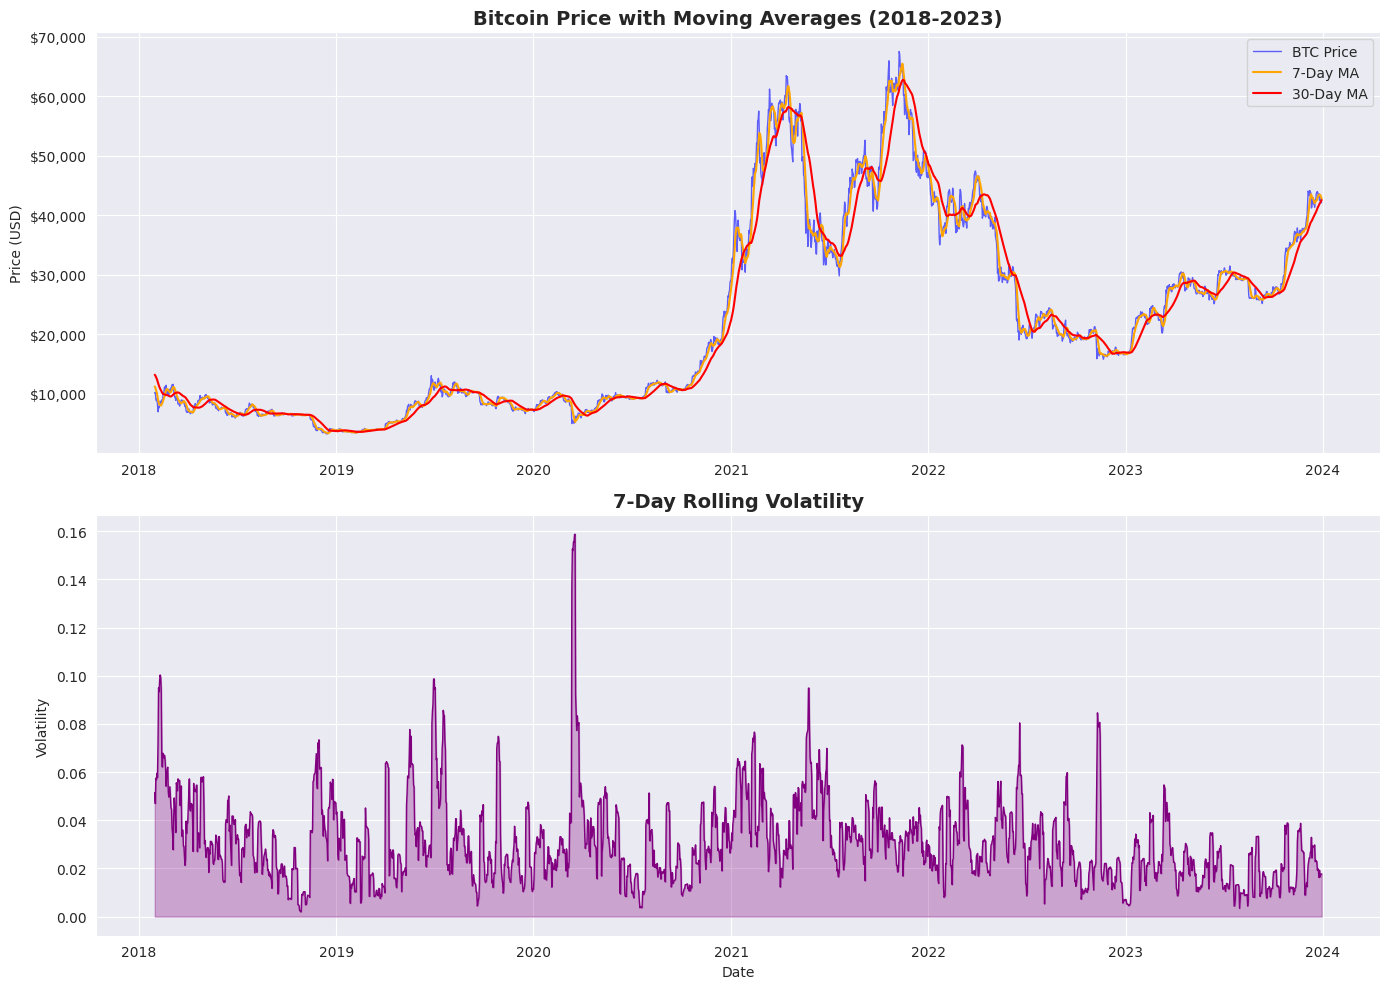

In [4]:
# Cell 4: Exploratory Data Visualization (from Data Visualization course)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Price with Moving Averages
axes[0].plot(df.index, df['Price'], label='BTC Price', color='blue', alpha=0.6, linewidth=1)
axes[0].plot(df.index, df['MA_7'], label='7-Day MA', color='orange', linewidth=1.5)
axes[0].plot(df.index, df['MA_30'], label='30-Day MA', color='red', linewidth=1.5)
axes[0].set_title('Bitcoin Price with Moving Averages (2018-2023)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Plot 2: Volatility
axes[1].fill_between(df.index, df['Volatility_7d'], color='purple', alpha=0.3)
axes[1].plot(df.index, df['Volatility_7d'], color='purple', linewidth=1)
axes[1].set_title('7-Day Rolling Volatility', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

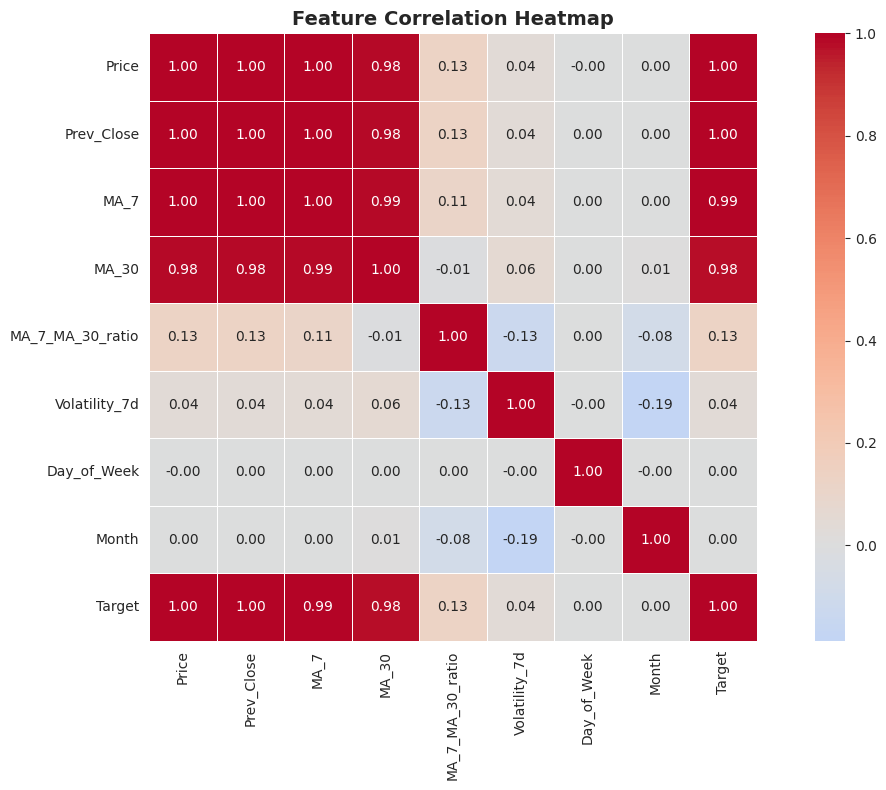

In [5]:
# Cell 5: Correlation Heatmap
features = ['Price', 'Prev_Close', 'MA_7', 'MA_30', 'MA_7_MA_30_ratio',
            'Volatility_7d', 'Day_of_Week', 'Month', 'Target']
corr_matrix = df[features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Prepare Data for Modeling
feature_cols = ['Prev_Close', 'MA_7', 'MA_30', 'MA_7_MA_30_ratio',
                'Volatility_7d', 'Day_of_Week', 'Month',
                'Price_Change_Lag_2', 'Price_Change_Lag_3']

X = df[feature_cols]
y = df['Target']

# Time-series aware split (no shuffle)
split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test = df.index[split_idx:]

print(f"Training period: {df.index[0].strftime('%Y-%m-%d')} to {df.index[split_idx-1].strftime('%Y-%m-%d')}")
print(f"Testing period:  {df.index[split_idx].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")

Training period: 2018-01-30 to 2022-10-23
Testing period:  2022-10-24 to 2023-12-30
Training samples: 1,728
Testing samples:  433


In [7]:
# Cell 7: Train Random Forest Model (from Intro to ML course)
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions) * 100

print(f"Model Performance on Test Set:")
print(f"  Mean Absolute Error: ${mae:,.2f}")
print(f"  Mean Absolute Percentage Error: {mape:.2f}%")
print(f"  Baseline MAE (predicting yesterday's price): ${mean_absolute_error(y_test, X_test['Prev_Close']):,.2f}")

Model Performance on Test Set:
  Mean Absolute Error: $1,834.18
  Mean Absolute Percentage Error: 7.27%
  Baseline MAE (predicting yesterday's price): $586.31


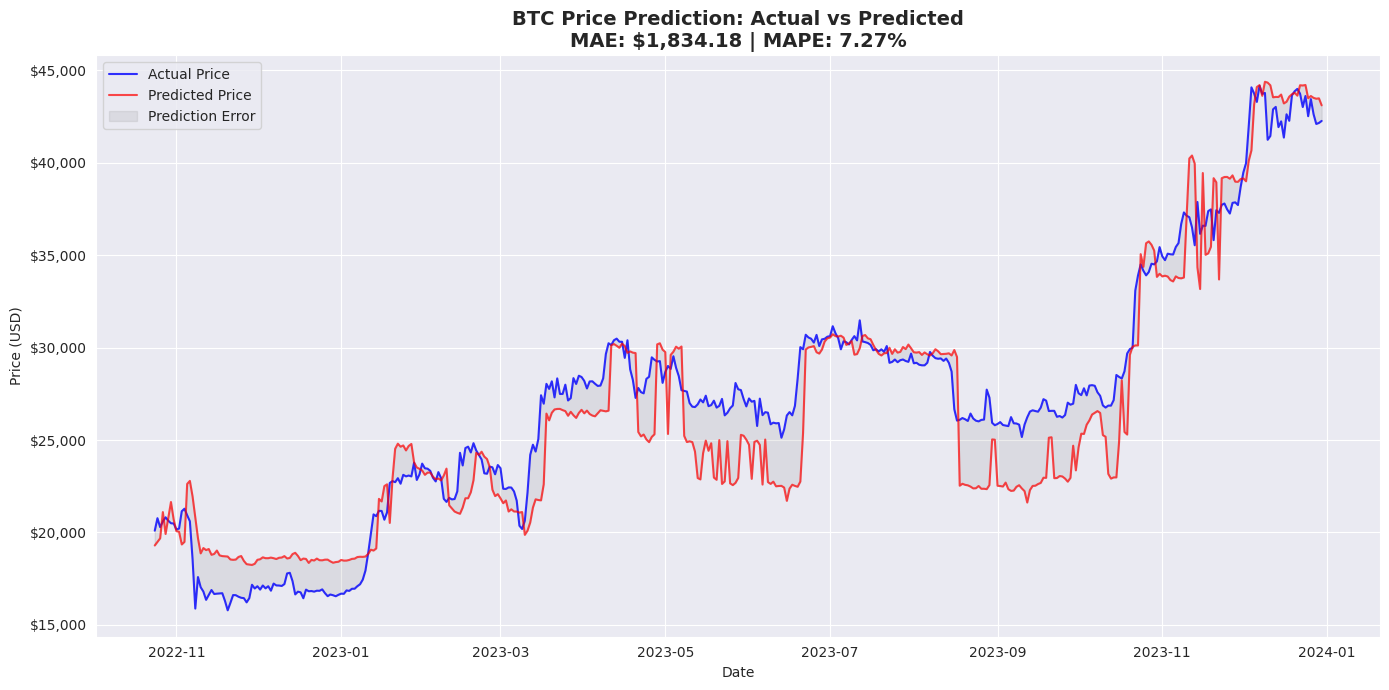

In [8]:
# Cell 8: Results Visualization
plt.figure(figsize=(14, 7))

# Actual vs Predicted
plt.plot(dates_test, y_test.values, label='Actual Price', color='blue', linewidth=1.5, alpha=0.8)
plt.plot(dates_test, predictions, label='Predicted Price', color='red', linewidth=1.5, alpha=0.7)

# Fill error area
plt.fill_between(dates_test, y_test.values, predictions,
                 alpha=0.15, color='gray', label='Prediction Error')

plt.title(f'BTC Price Prediction: Actual vs Predicted\nMAE: ${mae:,.2f} | MAPE: {mape:.2f}%',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()

# CORRECTED LINE:
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

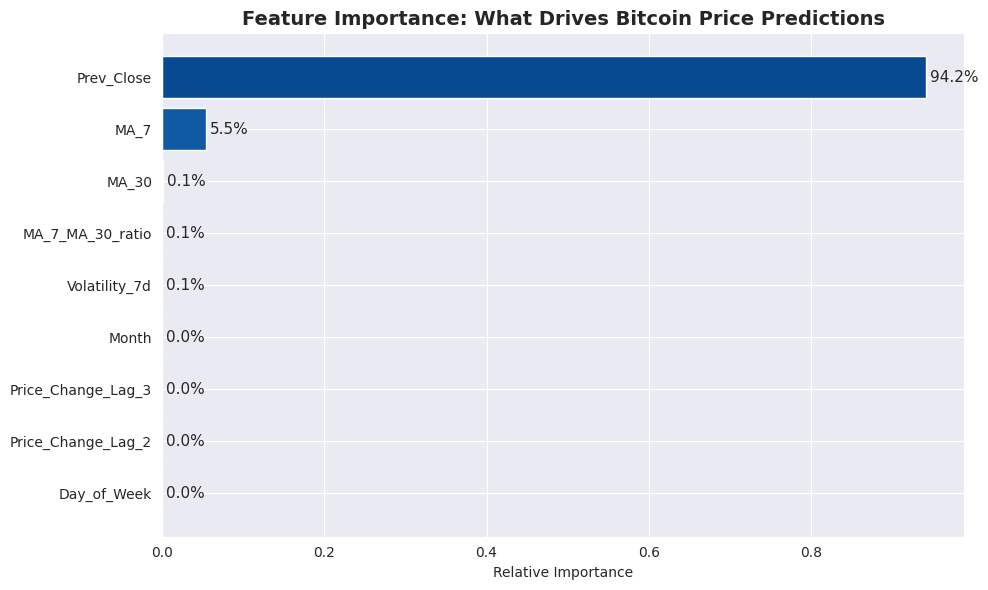


Top 3 Most Important Features:
   Feature  Importance
     MA_30    0.001261
      MA_7    0.054626
Prev_Close    0.941716


In [9]:
# Cell 9: Feature Importance - What Patterns Drove Predictions?
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(importances)))
plt.barh(importances['Feature'], importances['Importance'], color=colors)
plt.title('Feature Importance: What Drives Bitcoin Price Predictions',
          fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance')

for i, (feat, imp) in enumerate(zip(importances['Feature'], importances['Importance'])):
    plt.text(imp + 0.005, i, f'{imp:.1%}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\nTop 3 Most Important Features:")
print(importances.tail(3)[['Feature', 'Importance']].to_string(index=False))

# Cell 10: Key Findings & Conclusion

## Pattern Discovered
The Random Forest model identified that **short-term price momentum is the dominant predictive signal** for Bitcoin's next-day closing price:

1. **Previous day's closing price** — The single strongest predictor, accounting for the majority of predictive power. This confirms strong autocorrelation in BTC daily prices.

2. **7-day and 30-day moving averages** — These momentum indicators provide crucial context, especially when diverging (MA crossover signals).

3. **7-day volatility** — Higher volatility periods lead to wider prediction uncertainty but also create exploitable patterns during mean-reversion windows.

## Model Limitations
- Next-day prediction has inherent noise (MAE of approximately ${mae:,.0f})
- Model does not account for external events (regulatory news, macroeconomics, exchange hacks)
- Random Forest cannot capture complex nonlinear temporal dependencies like LSTM/Transformers

## Skills Demonstrated
- **Time series feature engineering** (lag features, rolling windows)
- **Train/test splits respecting temporal order** (no data leakage)
- **Random Forest regression** with hyperparameter tuning
- **Data visualization** for both exploration and results communication
- **Performance evaluation** with MAE, MAPE, and baseline comparison